# Generalized Integrate-and-Fire Neuron

In [1]:
#!pip install ANNarchy

This notebook explores the generalized Integrate-and-Fire neuron model being used for reproducing measured data.

Code based on:

> Schwalger, T., Deger, M., Gerstner, w. (2017). Towards a theory of cortical columns: From spiking neurons to interacting neural populations of finite size. PLoS Comput Biol. 2017;13(4):e1005507


In [2]:
import matplotlib.pyplot as plt
import numpy

import ANNarchy as ann

ANNarchy 5.0 (5.0.1) on linux (posix).


The generalized Integrate-and-Fire (GIF) neuron is defined by the following equations:

$$
    \tau_m \frac{du}{dt} = -u + u_r + R*I_{ext}
$$

$$
    \tau_v \frac{dv}{dt} = -(v-u_{th})
$$

Spike emission is the result of a stochastic process, where the threshold $\lambda$, also called hazard-rate, follows the difference between the membrane potential $u$ and an adaptive threshold $v$:

$$
    \lambda = c * exp(\frac{u-v}{\delta_{u}})
$$

The GIF neuron model is pre-implemented in ANNarchy, but with different default parameters compared to the above mentioned article. This refers mainly to the value range for the membrane potential and consequently the spike threshold. However, the parameters can be easily changed:

In [3]:
net = ann.Network()

# we adapt some of the default parameters for this example
mod_GIF = ann.GIF_curr(
    u_r     =   25.0,
    u_th    =   10.0,
    c       =   10.0,
    delta_u =    5.0,
    I_ext   =    0.0,
    current = ""
)

Using this adapted neuron type, we can now create our population:

In [4]:
# create the population
P = net.create(500, neuron=mod_GIF)

# select only one neuron
m = net.monitor(P[15], ["Lambda", "p", "u", "v", "spike"])

# record spikes of all neurons
m2 = net.monitor(P, "spike")

net.compile()

# just for logging
input_signal = numpy.zeros(600)

# -> mu = 15 mv
P.I_ext = (15 - P.u_r)/P.R
net.simulate(300)
input_signal[:300] = P.I_ext

# -> mu = 30 mv
P.I_ext = (30 - P.u_r)/P.R
net.simulate(300)
input_signal[300:] = P.I_ext

Compiling network 1... 

OK


Text(0.5, 0, 'biological time [ms]')

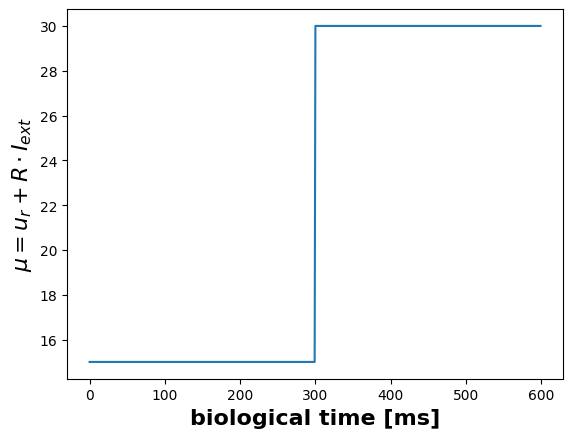

In [5]:
plt.figure()
plt.plot(P.u_r + P.R * input_signal)
plt.ylabel(r"$\mu = u_r + R \cdot I_{ext}$", fontsize=16, fontweight="bold")
plt.xlabel("biological time [ms]", fontsize=16, fontweight="bold")

Text(0.5, 0, 'biological time [ms]')

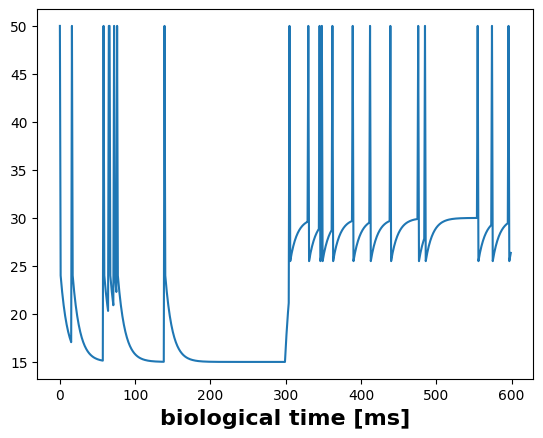

In [6]:
plt.figure()
u_data = m.get("u")
spikes = m.get("spike")[15]
u_data[spikes] = 50   # arbitrary value to highlight the spike
plt.plot(u_data)
plt.xlabel("membrane potential [mV]", fontsize=16, fontweight="bold")
plt.xlabel("biological time [ms]", fontsize=16, fontweight="bold")

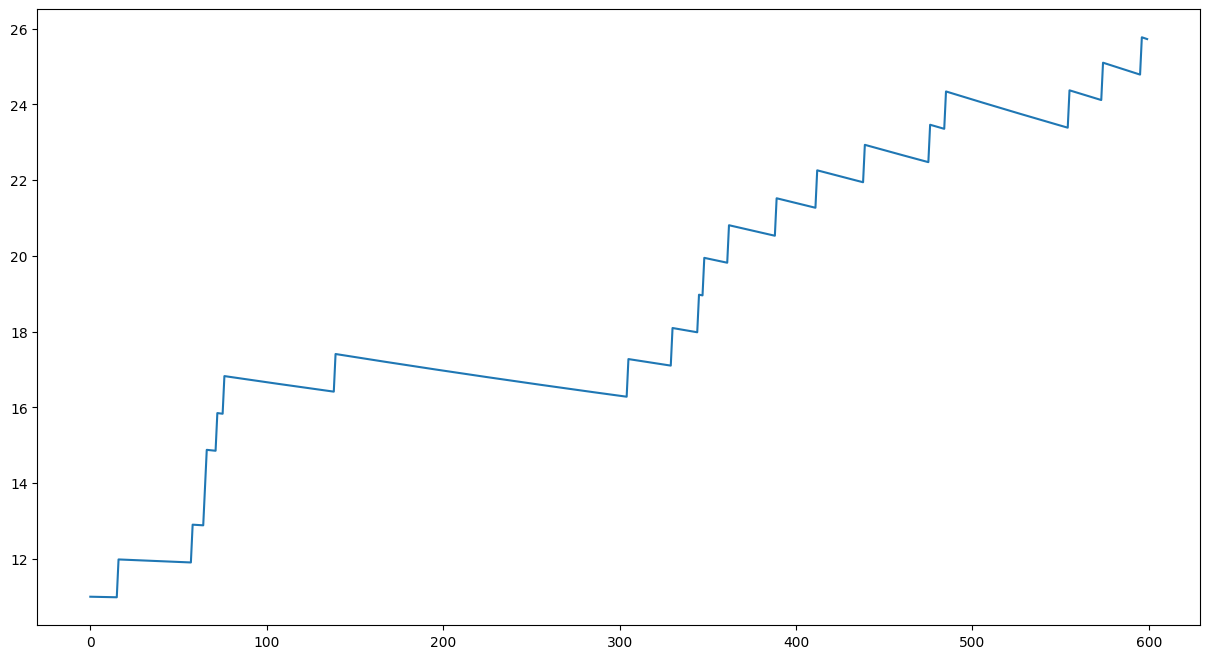

In [7]:
plt.figure(figsize=(15, 8))
v_data = m.get("v")
plt.plot(v_data)

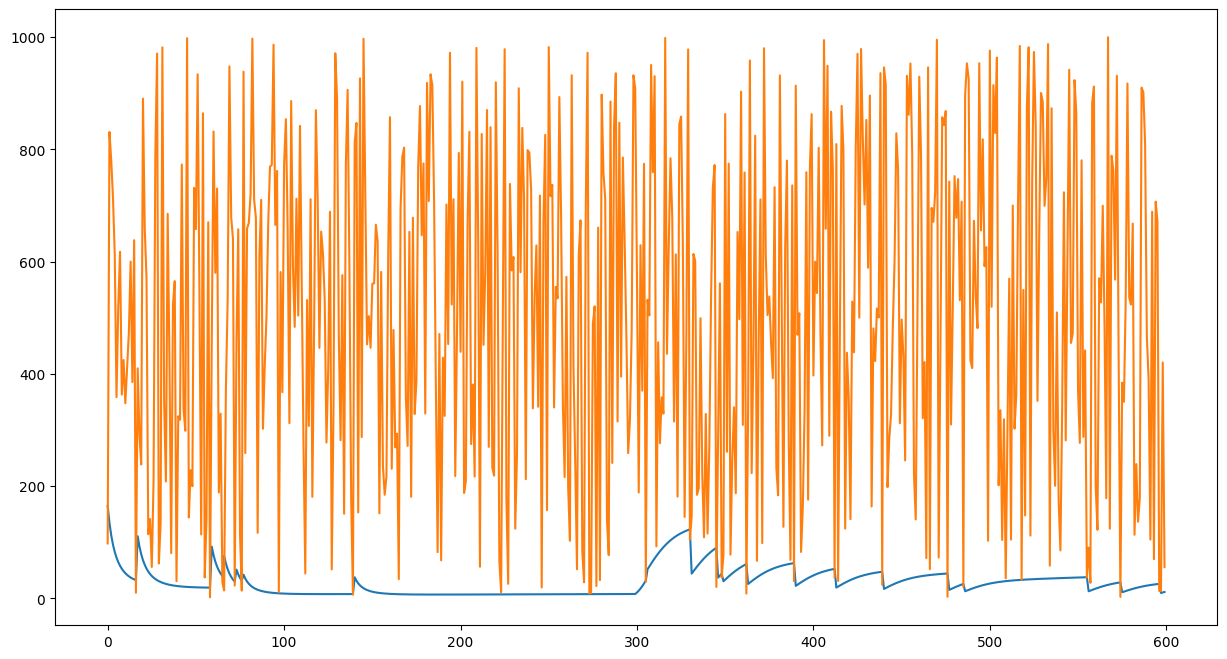

In [8]:
plt.figure(figsize=(15, 8))
lamda_data = m.get("Lambda")
plt.plot(lamda_data)

p_data = m.get("p")
plt.plot(p_data)

In [9]:
spikes = m2.get("spike")

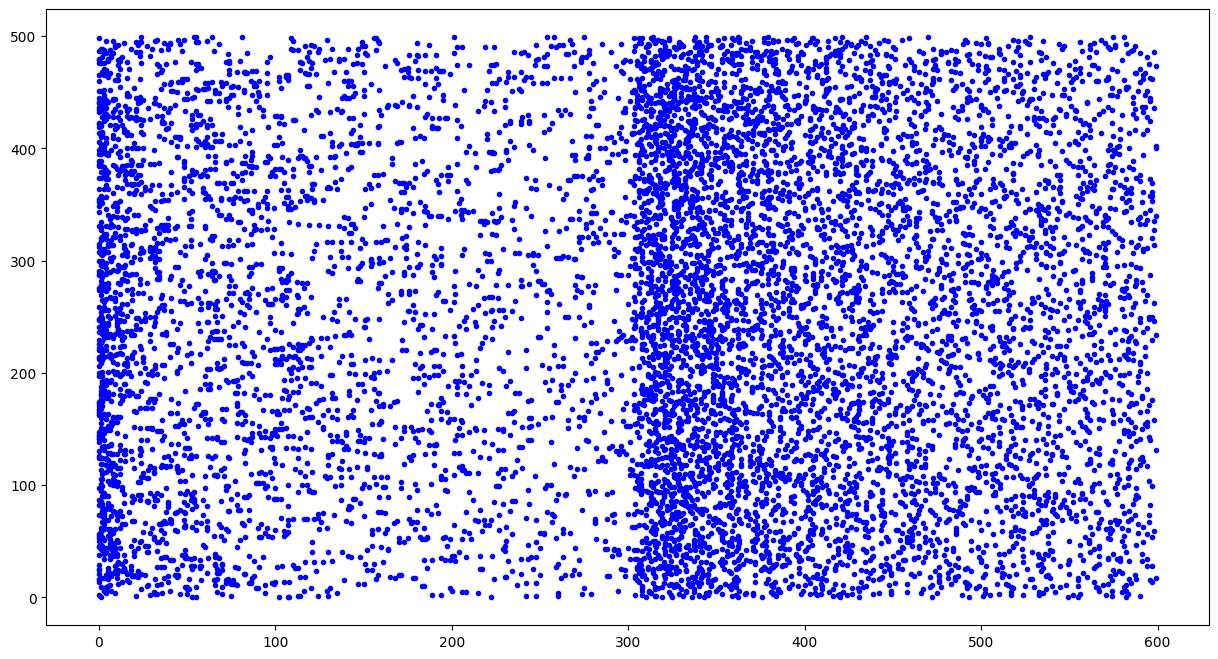

In [10]:
plt.figure(figsize=(15, 8))
t, n = m2.raster_plot(spikes)
plt.plot(t, n, "b.")


11.406666666666666
21.233333333333334


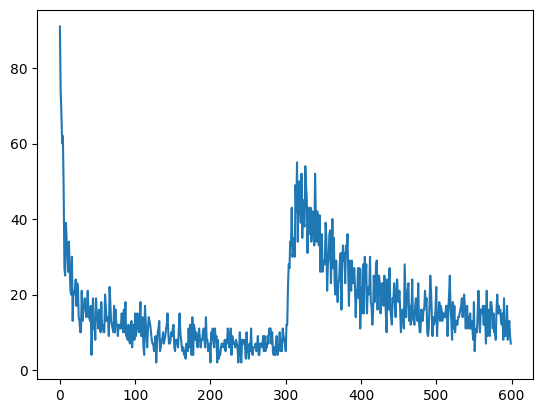

In [11]:
fr = m2.histogram(spikes)
plt.plot(fr)

print(numpy.mean(fr[:300]))
print(numpy.mean(fr[300:]))

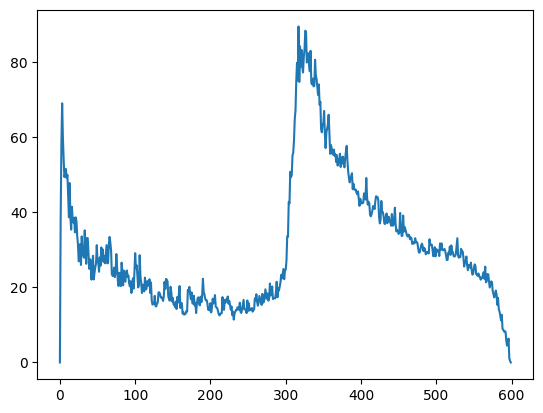

In [12]:
smooth_fr = m2.smoothed_rate(spikes, 1.0) # 1ms window
plt.plot(numpy.mean(smooth_fr, axis=0))